# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 2. Детекция объектов.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

Сыграем в квиддич? Или лучше в карты?

В этом дз вам предстоит написать практически с нуля архитектуру для детекции, а также воспользоваться готовым решением. На выбор даётся два датасета, отличаются они только картинками. Форматы, баллы - все одинаково.

Первый вариант это датасет по кадрам игры в квиддич из Гарри Поттера. Если вы забыли правила, то нажмите [сюда](https://harrypotter.fandom.com/ru/wiki/%D0%9A%D0%B2%D0%B8%D0%B4%D0%B4%D0%B8%D1%87). Вы научитесь искать и выделять на фотографиях бладжеры, квоффл и снитч.

Второй вариант это датасет с игральными картами. Если вы забыли что такое карты, то нажмите [сюда](https://ru.wikipedia.org/wiki/%D0%98%D0%B3%D1%80%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B5_%D0%BA%D0%B0%D1%80%D1%82%D1%8B). Вы научитесь искать и выделять на фотографиях несколько типов карт.

Оба варианта содержат около 300 картинок, данные хранятся в xml в формате PascalVOC. Есть малые отличия, но ничего страшного.


Если с самописным детектором совсем не получается, то можно после создания датасетов перейти к концу, где обучается готовый, с ним будет проще :)

### Консультация 2023 года

https://www.youtube.com/watch?v=oCwEmKW3bYg

# Notes

Дз проверялось на работоспособность в colab. Не гарантируется, что будет работать на чем-то другом. На Windows, скорее всего, вас ждет немало проблем :(

## Данные

Скачайте один из датасетов на свой вкус и начните работу с ним.
Разметка находится в xmls папке, картинки в images.

In [1]:
!wget https://github.com/markblumenau/hw3_iad_dl/raw/main/harry/data.zip

--2026-01-18 18:54:13--  https://github.com/markblumenau/hw3_iad_dl/raw/main/harry/data.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/markblumenau/hw3_iad_dl/main/harry/data.zip [following]
--2026-01-18 18:54:13--  https://raw.githubusercontent.com/markblumenau/hw3_iad_dl/main/harry/data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17592727 (17M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]  16.78M  --.-KB/s    in 0.1s    

2026-01-18 18:54:14 (174 MB/s) - ‘data.zip’ saved [17592727/17592727]



In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00


In [3]:
# Harry Potter -- uncomment
#!wget https://github.com/markblumenau/hw3_iad_dl/raw/main/harry/data.zip

# Cards -- uncomment
#!wget https://github.com/markblumenau/hw3_iad_dl/raw/main/cards/data.zip
import glob
import shutil
from pathlib import Path
from xml.etree import ElementTree as ET

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import ultralytics
from albumentations.pytorch.transforms import ToTensorV2
from matplotlib.patches import Rectangle
from PIL import Image
from torch import nn
from torchvision.models import ResNet50_Weights
from tqdm.notebook import tqdm

!unzip -q data.zip

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Задача 1. 0.5 балла.

Ниже написан код для стандартного Dataset из библиотеки pytorch. Dataset требует реализации `__getitem__` и `__len__` методов. Далее эти методы будут использованы для формирования батчей для обучения. Поскольку читать придется из xml файлов, нужно перед этим дописать функцию get_xml_data, чтобы по названию картинки подтягивать аннотации.

Функции можно и нужно передать некий class_dict. Он есть и при инициализации датасета ниже. С его помощью можно название класса превратить в int. Далее подразумевается, что класс идёт как int.

In [4]:
def get_xml_data(image_name, root, class_dict, xml_prefix="/xmls/"):
    # get smth like ZZZ/YYY/XXXXXX.jpg -> XXXXXX
    filename = image_name.split("/")[-1].split(".")[0]
    # read xml
    tree = ET.parse(str(root) + xml_prefix + filename + ".xml")
    treeroot = tree.getroot()
    # iterate over bboxes
    bboxes = []
    for member in treeroot.findall("object"):
        # 1) название класса
        cls_name = member.find("name").text.strip()
        cls_id = int(class_dict[cls_name])  # строка -> int

        # 2) bbox координаты
        bnd = member.find("bndbox")
        xmin = int(float(bnd.find("xmin").text))
        ymin = int(float(bnd.find("ymin").text))
        xmax = int(float(bnd.find("xmax").text))
        ymax = int(float(bnd.find("ymax").text))

        # you need: xmin ymin xmax ymax, class in dict
        # то есть res выглядит как [xmin, ymin, xmax, ymax, class]
        # всё в int!
        # Для корректной работы клеточек ниже требуется конкретная последовательность координат
        # См. доку https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/
        # Нас интересует pascal_voc формат, далее применяется он.

        res =  [xmin, ymin, xmax, ymax, cls_id] #тут уже все координаты лежат

        bboxes.append(res)

    return bboxes

In [5]:
#проверяем корректность функции - определи root и img_path
from pathlib import Path

root = Path("/content/data")
img_path = root / "images" / "102.jpg"

print("img_path:", img_path)
print("exists:", img_path.exists())


img_path: /content/data/images/102.jpg
exists: True


In [6]:
#есть нужный XML именно для 102
xml_path = root / "xmls" / "102.xml"
print("xml_path:", xml_path)
print("exists:", xml_path.exists())


xml_path: /content/data/xmls/102.xml
exists: True


In [7]:
#class_dict существует
from pathlib import Path
import xml.etree.ElementTree as ET

root = Path("/content/data")
xml_dir = root / "xmls"

xml_files = sorted(xml_dir.glob("*.xml"))
print("num xml files:", len(xml_files))
print("example xml:", xml_files[0])



num xml files: 283
example xml: /content/data/xmls/0.xml


In [8]:
#достаём все названия классов
classes = set()

for xml_path in xml_files:
    tree = ET.parse(str(xml_path))
    treeroot = tree.getroot()
    for obj in treeroot.findall("object"):
        cls_name = obj.find("name").text.strip()
        classes.add(cls_name)

classes = sorted(classes)
print("classes:", classes)
print("num classes:", len(classes))


classes: ['bludger', 'quaffle', 'snitch']
num classes: 3


In [9]:
#делаем class_dict и обратный словарь
class_dict = {name: i for i, name in enumerate(classes)}
class_dict_inv = {i: name for name, i in class_dict.items()}

print("class_dict :", list(class_dict.items())[:10])


class_dict : [('bludger', 0), ('quaffle', 1), ('snitch', 2)]


-------
Комментарий: Проверили, что функция работает корректно. Функция должна по имени картинки найти XML‑файл, прочитать его (xml.etree.ElementTree), достать координаты всех прямоугольников и метки классов, а затем превратить их в массив [xmin, ymin, xmax, ymax, class_id]. Класс берётся из class_dict (ключ это строковое название из XML, значение это номер класса). Возврат должен быть списком прямоугольников.

In [10]:
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", train=True, seed=42):
        self.root = Path(root)
        self.transform = transform

        assert self.root.is_dir(), f"No data at `{root}`"

        self.filenames = np.array(glob.glob(root + "/images/*"))
        with open(str(self.root) + "/class_dict", "r") as f:
            self.class_dict = eval(f.readline())

        self.class_dict_inv = {v: k for k, v in self.class_dict.items()}

        np.random.seed(seed)
        permutation = np.random.permutation(len(self.filenames))

        # Train/test split
        if train:
            self.filenames = self.filenames[
                permutation[: int(len(self.filenames) * 0.9)]
            ].tolist()
        else:
            self.filenames = self.filenames[
                permutation[int(len(self.filenames) * 0.9) :]
            ].tolist()

    def __getitem__(self, idx):
        # Нужно обладая файлнеймом подгрузить картинку и бибоксы, функцию для подгрузки бибоксов вы дописали выше :)
        fname = self.filenames[idx]
        # 1)читаем изображение
        image = Image.open(fname).convert("RGB")
        image = np.array(image)  # HWC

        # 2)читаем bbox из xml
        bboxes = get_xml_data(fname, self.root, self.class_dict)

        # 3)применяем трансформы (resize+normalize+to tensor)
        out = self.transform(image=image, bboxes=bboxes)

        # transform будут объявлены ниже за вас
        # Но библиотека привередлива к формату данных на входе, внимательно прочтите прошлую клеточку

        #4) приводим bboxes к torch.Tensor
        # координаты после resize станут float
        out["bboxes"] = torch.tensor(out["bboxes"], dtype=torch.float32)
        return out

    def __get_raw_item__(self, idx):
        fname = self.filenames[idx]
        return fname, get_xml_data(fname, self.root, self.class_dict)

    def __len__(self):
        return len(self.filenames)

---------------
Комментарий:
Реализовала кастомный Dataset для детекции:
- в __init__ собираю список картинок, читаю class_dict и делаю train/test split 90/10 с фиксированным seed
- в __getitem__ по имени файла загружаю изображение и bbox из xml (формат pascal_voc), затем применяю albumentations transform (Resize->Normalize->ToTensorV2), чтобы привести картинки к 512x512
- и автоматически пересчитать координаты bbox после resize
- bboxes дополнительно привожу к torch.Tensor для удобства дальнейшей сборки батча в collate_fn
- __len__ возвращает количество файлов


Ниже определяем стандартные нормализации и приведение размера к 512x512.


In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [12]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std), #несовместимость версий Albumentations, скорректировала на A.Normalize(...)
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(format="pascal_voc", min_visibility=0.3),
)

test_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(format="pascal_voc", min_visibility=0.5),
)


In [13]:
train_ds = PascalDataset(root="./data/", transform=train_transform, train=True)
test_ds = PascalDataset(root="./data/", transform=test_transform, train=False)

# Задача 2. 1 балл.

Теперь, когда мы загрузили данные, хорошо бы посмотреть на них, прежде чем обучать какие-либо модели. Напишите функцию `visualize`, которая принимает списки изображений и прямоугольников в качестве входных данных и рисует эти прямоугольники на изображениях.

В датасете есть class_dict_inv, который позволит вам сделать обратное преобразование: int, содержащий класс, в строку с названием.


Полезные функции:
* [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) -- легко создавать несколько изображений в одной pyplot figure
* [ax.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) -- отображение графиков (не забудьте откатить нормализацию)
* [ax.text](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html), [patches.Rectangle](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html) -- для рисования прямоугольников и текста с аннотацией

In [14]:
def visualize(images, bboxes):
    mean = np.array((0.485, 0.456, 0.406), dtype=np.float32)
    std = np.array((0.229, 0.224, 0.225), dtype=np.float32)

    fig, axes = plt.subplots(
        2, len(images) // 2 + len(images) % 2, figsize=(10, 8), dpi=100
    )

    for i, ax in enumerate(axes.reshape(-1)):

        ax.axis(False)

        if i >= len(images):
            break

        # 1)взять картинку
        img = images[i]
        if torch.is_tensor(img):
            img = img.detach().cpu()

        # 2)CHW -> HWC для matplotlib
        img = img.permute(1, 2, 0).numpy()

        # 3) откатить нормализацию
        img = (img * std + mean).clip(0, 1)

        # Вот тут нужно выполнить permute (вспомните где у torch каналы, а где они у matplotlib)
        # И откатить нормализацию (просто обратное преобразование)
        # Имена и количества классов можно подтянуть из датасета через train_ds.class_dict_inv

        # 4) показать картинку
        # Вот тут покажите картинку после отката нормализации
        ax.imshow(img)

        # 5) нарисовать боксы
        boxes_i = bboxes[i]
        if torch.is_tensor(boxes_i):
            boxes_i = boxes_i.detach().cpu().numpy()


        for bbox in bboxes[i]:
        # Вот тут нарисуйте бибоксы
            xmin, ymin, xmax, ymax, cls_id = bbox
            xmin, ymin, xmax, ymax = float(xmin), float(ymin), float(xmax), float(ymax)
            cls_id = int(cls_id)

            w = xmax - xmin
            h = ymax - ymin

            rect = patches.Rectangle(
                (xmin, ymin),
                w,
                h,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

            if class_dict_inv is not None:
                label = class_dict_inv.get(cls_id, str(cls_id))
                ax.text(
                    xmin,
                    ymin,
                    label,
                    fontsize=10,
                    color="white",
                    bbox=dict(facecolor="red", alpha=0.6, pad=1),
                )

    fig.tight_layout()
    plt.show()

У вас должно получиться что-то похожее на изображения для датасета с масками:

![image](https://i.imgur.com/V5TUT26.png)

In [15]:
import matplotlib.patches as patches

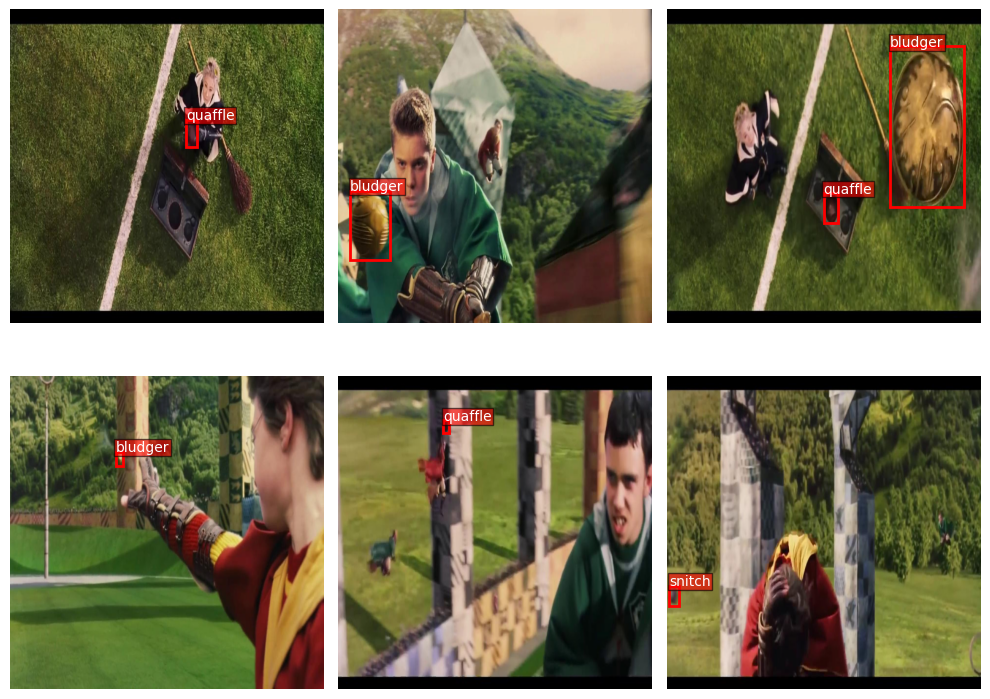

In [16]:
out = [train_ds[i] for i in range(6)]
visualize([o["image"] for o in out], [o["bboxes"] for o in out])

----

Комментарий: Сделала функцию визуализации, чтобы до обучения проверить корректность разметки. Откатываю нормализацию (mean/std), перевожу тензор из CHW в HWC для matplotlib и рисую bbox в формате pascal_voc через patches.Rectangle.

# Задача 3. 3 балла.
## YOLO-like детектор

Сейчас нам предстоить реализовать детектор, похожий на YOLO. Это один из самых простых детекторов с точки зрения реализации. YOLO описан в статье: [You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640). Здесь мы его немного изменим и упростим. Будем использовать ResNet для извлечения признаков. На выходе мы будем получать карту признаков размера 16x16.

## Задача 3.1. 1 балл.

Первым делом нам нужно реализовать collate function. Это функция позволит нам кастомизировать, как именно батч конструируется из примеров (смотрите [pytorch docs](https://pytorch.org/docs/stable/data.html#dataloader-collate-fn) для деталей).

Это функция должна принять на вход лист прямоугольников и вернуть тензор размера Bx6x16x16. Первая размерность - это количество примеров в батче. Вторая -- "каналы", суть которых написана чуть ниже. Далее идут две пространственные размерности, это сетка 16 на 16. Зафиксируем порядок координат как (y, x) для этой сетки 16 на 16. Это значит, что в target идут ```cy_idx, cx_idx``` в таком порядке, см. код.

В шести "каналах" у нас будут записаны:
* Сдвиги центра bbox относительно начала клеточки (клеточка это "гиперпиксель" на изображении 16 на 16 на выходе сети). Записаны эти сдвиги будут в клеточку, к которой относятся. 2 канала (X, Y)
* Нормализованные ширина и высота bbox. 2 канала (W, H)
* Confidence сетки. Им мы будем пользоваться, чтобы фильтровать уверенность сетки в наличии bbox в данной клетке. Таргет содержит 1 там, где bbox есть, и 0 иначе. 1 канал
* Класс детекции (тот самый int, полученный из строки с названием)

### Пояснительная картинка.

Она обладает некоторым уровнем абстракции, чёрных например должно быть 512, а зелёная должна захватывать 32 маленькие черные. Но может будет понятнее :)

![image](https://i.imgur.com/13YVxAd.jpeg)

In [17]:
def collate_fn(batch, downsample=32):
    imgs, batch_boxes = map(list, (zip(*[(b["image"], b["bboxes"]) for b in batch])))

    imgs = torch.stack(imgs)
    b, _, h, w = imgs.shape

    # 6 каналов cx_offset, cy_offset, w_norm, h_norm, obj, class_id
    target = imgs.new_zeros(b, 6, h // downsample, w // downsample)

    # Add sample index to targets
    for i, boxes in enumerate(batch_boxes):
        xmin, ymin, xmax, ymax, classes = map(
            torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)
        )

        # Нормализуйте ширину и высоту, поделив на ширину и высоту исходного изображения
        # размер клетки в пикселях
        x_cell =  w / (w // downsample)   # для 512 и 32 -> 32
        y_cell =  h / (h // downsample)

        # ширина и высота бибокса могут превышать размеры гиперпикселя
        # поэтому их мы нормируем на полноценные 512

        # ширина/высота бокса, нормированные на размер картинки
        w_box = (xmax - xmin) / w
        h_box = (ymax - ymin) / h

        # Посчитайте координаты центра и сдвиги

        # центр бокса в пикселях (в координатах исходной картинки 512x512)
        cx =  (xmin + xmax) / 2
        cy = (ymin + ymax) / 2

        # индекс клетки (0..15)
        cx_idx =  (cx / x_cell).floor().long()
        cy_idx = (cy / y_cell).floor().long()

        #если центр ровно на границе и улетел в 16
        cx_idx = cx_idx.clamp(0, w // downsample - 1)
        cy_idx = cy_idx.clamp(0, h // downsample - 1)

        # смещение центра внутри клетки (в долях клетки, 0..1)
        cx_box = (cx - cx_idx * x_cell) / x_cell
        cy_box = (cy - cy_idx * y_cell) / y_cell

        #  сначала y, потом x (как в картинке/матрице)
        target[i, :, cy_idx, cx_idx] = torch.stack(
            [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes]
        )

    return {"image": imgs, "target": target}

------
Комментарий:

Реализовала кастомную collate_fn для детекции: преобразую список примеров (image, bboxes) в формат, удобный для YOLO-подобного обучения. Изображения стакаются в батч, а аннотации конвертируются в плотный тензор-цель (B, 6, 16, 16), где каждая клетка отвечает за один объект, чей центр попал в неё.

В целевом тензоре храню offsets центра в пределах клетки, нормированные размеры bbox, objectness и id класса.


Следующей функцией Вы можете проверить свою реализацию. Проверка не является блокирующей и в теории можно написать корректное решение, которое её не пройдет.

In [18]:
def test_collate_fn() -> None:
    target1 = [100, 200, 200, 300, 2]  # xmin,ymin,xmax,ymax,class
    target2_1 = [0, 250, 200, 300, 0]  # xmin,ymin,xmax,ymax,class
    target2_2 = [0, 100, 100, 300, 1]  # xmin,ymin,xmax,ymax,class

    result = collate_fn(
        [
            {"image": torch.rand((3, 512, 512)), "bboxes": [target1]},
            {"image": torch.rand((3, 512, 512)), "bboxes": [target2_1, target2_2]},
        ]
    )

    # Проверяем размерности
    assert result["image"].shape == (2, 3, 512, 512)
    assert result["target"].shape == (2, 6, 16, 16)

    # Проверяем значения клеточек, в которые попали ббоксы
    assert np.allclose(
        result["target"][0, :, 7, 4],
        torch.tensor([22 / 32, 26 / 32, 100 / 512, 100 / 512, 1, 2]),
    )
    assert np.allclose(
        result["target"][1, :, 8, 3],
        torch.tensor([4 / 32, 19 / 32, 200 / 512, 50 / 512, 1, 0]),
    )
    assert np.allclose(
        result["target"][1, :, 6, 1],
        torch.tensor([18 / 32, 8 / 32, 100 / 512, 200 / 512, 1, 1]),
    )

    # Проверяем, что все остальные клеточки содержат нули
    result["target"][0, :, 7, 4] = result["target"][1, :, 8, 3] = result["target"][
        1, :, 6, 1
    ] = torch.zeros(6)
    assert np.allclose(result["target"], 0)


test_collate_fn()

Ниже вы можете увидеть пример, как выглядит решетка размера 16 на 16 на исходном изображении:

/tmp/ipython-input-2780359046.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(train_ds[i]["bboxes"])


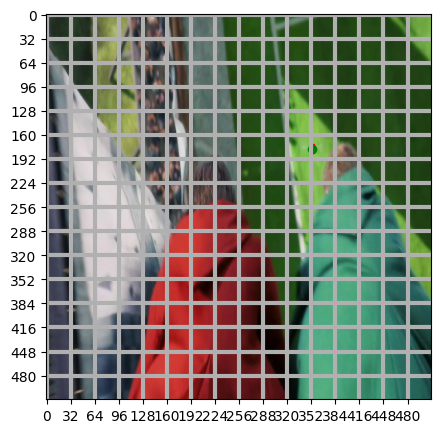

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
i = 20

img = train_ds[i]["image"].permute(1, 2, 0) * torch.tensor(std).view(
    1, 1, -1
) + torch.tensor(mean).view(1, 1, -1)
bboxes = torch.tensor(train_ds[i]["bboxes"])

ax.imshow(img)
loc = plt.matplotlib.ticker.MultipleLocator(base=32)
ax.xaxis.set_major_locator(loc)
ax.yaxis.set_major_locator(loc)
ax.grid(which="major", axis="both", linestyle="-", linewidth=3)

for bbox in bboxes:
    xmin, ymin, xmax, ymax = bbox[:-1]
    w = xmax - xmin
    h = ymax - ymin
    with_mask = bbox[-1]
    ax.add_patch(Rectangle((xmin, ymin), w, h, fill=False, color="red"))

cx = (bboxes[:, 0] + bboxes[:, 2]) / 2
cy = (bboxes[:, 1] + bboxes[:, 3]) / 2

ax.scatter(cx, cy, color="green", marker="o")

plt.show()

-------
### Проверочка

Проверила корректность collate_fn на реальном примере: вычисленный индекс клетки (6,8) совпал с положением центра bbox на сетке 16×16, а offsets и нормированные размеры совпали с ручным пересчётом. Значит таргет формируется корректно.

In [20]:
i = 20  # индекс
raw = train_ds[i]

b = raw["bboxes"]
if not torch.is_tensor(b):
    b = torch.tensor(b)

# возьмем первый bbox
xmin, ymin, xmax, ymax, cls = b[0]

cx = (xmin + xmax) / 2
cy = (ymin + ymax) / 2

cx_idx = int(torch.floor(cx / 32).item())
cy_idx = int(torch.floor(cy / 32).item())

print("bbox:", b[0].tolist())
print("center:", cx.item(), cy.item())
print("cell idx (x,y):", cx_idx, cy_idx)


bbox: [350.3999938964844, 172.33518981933594, 356.0, 184.4916229248047, 0.0]
center: 353.20001220703125 178.4134063720703
cell idx (x,y): 11 5


In [21]:
res = collate_fn([train_ds[i]])
t = res["target"][0]   # (6,16,16)

print("target at cell:", t[:, cy_idx, cx_idx])


target at cell: tensor([0.0375, 0.5754, 0.0109, 0.0237, 1.0000, 0.0000])


/tmp/ipython-input-1533666410.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)


## Задача 3.2. 0.5 балла.

Выход нашей сетки будет несколько больше, чем Bx6x16x16. Почему?

Мы решаем задачу, где классов больше одного. Вспомним прошлое дз: target был одним числом, но выход сетки содержал длинный-длинный вектор, из которого мы получали вероятность принадлежности к тому или иному классу. Здесь то же самое, но как бы в двумерии: у каждой клеточки из этих 16*16 будет свой вектор длины C, который мы будем использовать для определения класса.

Реализуйте обратное относительно collate_fn преобразования, чтобы декодировать выход нейронной сети. Применив функцию decode_prediction к выходу collate function вы должны получить изначальный набор прямоугольников с корректными размерами и координатами, а также классами. Применив к выходу нейросети мы тоже должны получить набор прямоугольников и тоже с корректными классами.

То есть, нужно проделать операции из collate_fn в обратную сторону, но учесть, что у неройнки выход будет чуть длиннее, и там мы должны брать argmax для определения класса.

Hint: в target classes идут в конце. В нейронке они тоже будут в конце, но их будет больше 1. Можно проверять число каналов пришедшего объекта, если оно 6, то перед нами target и надо брать значение, которое записано в клеточке. Иначе (каналов больше 6) перед нами выход нейронки, и надо брать самый вероятный из них.

In [22]:
from typing import List

In [23]:
def decode_prediction(pred, upsample=32, threshold=0.7) -> List[List[List[float]]]:
    b, c, h, w = pred.shape
    img_w, img_h = w * upsample, h * upsample
    result = []

    for bi in range(b):
        boxes_img = []
        for y in range(h):
            for x in range(w):
                conf = float(pred[bi, 4, y, x].item())
                if conf < threshold:
                    continue

                cx_offset = float(pred[bi, 0, y, x].item())
                cy_offset = float(pred[bi, 1, y, x].item())
                w_norm = float(pred[bi, 2, y, x].item())
                h_norm = float(pred[bi, 3, y, x].item())

                cx = (x + cx_offset) * upsample
                cy = (y + cy_offset) * upsample

                bw = w_norm * img_w
                bh = h_norm * img_h

                xmin = cx - bw / 2
                ymin = cy - bh / 2
                xmax = cx + bw / 2
                ymax = cy + bh / 2

                if c == 6:
                    cls_id = int(pred[bi, 5, y, x].item())
                else:
                    cls_id = int(torch.argmax(pred[bi, 5:, y, x]).item())

                # делаем формат как в исходных bboxes (int координаты + int класс)
                xmin = int(round(xmin))
                ymin = int(round(ymin))
                xmax = int(round(xmax))
                ymax = int(round(ymax))

                boxes_img.append([xmin, ymin, xmax, ymax, cls_id])

        result.append(boxes_img)

    return result


----
Комментарий:

decode_prediction делает обратное преобразование к collate_fn: из карты (B, C, 16, 16) восстанавливаю список bbox в пиксельных координатах.

Беру только клетки с objectness выше threshold, перевожу offsets центра из долей клетки в пиксели (upsample=32), ширину/высоту из нормированных значений в пиксели (умножая на размер изображения), класс беру либо напрямую (если каналов 6, как у target), либо через argmax по class-каналам (если это выход модели).


Следующей функцией Вы можете проверить свою реализацию. Проверка не является блокирующей.

In [24]:
def test_decode_predictions() -> None:
    # Применяем collate_fn к некоторым данным
    target1 = [[100, 200, 200, 300, 2]]
    target2 = [[0, 250, 200, 300, 0], [0, 100, 100, 300, 1]]
    result = collate_fn(
        [
            {"image": torch.rand((3, 512, 512)), "bboxes": target1},
            {"image": torch.rand((3, 512, 512)), "bboxes": target2},
        ]
    )

    target = result["target"]
    assert target.shape == (2, 6, 16, 16)
    # В таком виде target соответствует поиску одного класса - 6-ой канал.
    # Добавим еще 2 канала, чтобы проверить работу функции для нескольких классов
    target = torch.cat(
        [target, torch.zeros(2, 2, 16, 16)], dim=1
    )  # Добавляем два канала
    assert target.shape == (2, 8, 16, 16)  # Теперь их стало 8

    target[0, 5:, 7, 4] = torch.tensor([0.5, 0.6, 0.9])  # класс 2
    target[1, 5:, 8, 3] = torch.tensor([0.9, 0.6, 0.5])  # класс 0
    target[1, 5:, 6, 1] = torch.tensor([0.6, 0.9, 0.5])  # класс 1

    # Считаем результат
    actual = decode_prediction(target)
    print("Actual:  ", actual)

    # Порядок ббоксов для target2 может меняться в зависимости от вашей реализации и это не ошибка.
    # Скорее всего, он будет такой. Но если ассерт не проходит, попробуйте поменять их местами.
    expected = [target1, [target2[1], target2[0]]]
    # expected = [ target1, [ target2[0], target2[1] ] ] # <-- такой ответ тоже правильный.
    print("Expected:", expected)

    # Сравниваем
    assert actual == expected


test_decode_predictions()

Actual:   [[[100, 200, 200, 300, 2]], [[0, 100, 100, 300, 1], [0, 250, 200, 300, 0]]]
Expected: [[[100, 200, 200, 300, 2]], [[0, 100, 100, 300, 1], [0, 250, 200, 300, 0]]]


----
Комментарий:

При декодировании координаты получаются float из-за нормализаций/делений, поэтому для сравнения с исходной разметкой и прохождения теста округляю их до int.

## Задача 3.3. 1 балл.
Реализуйте модель. Первым делом примените первые 4 блока (до layer4 включительно, можно при помощи ```list(model.children())[:-2]```) ResNet50. Далее добавьте несколько блоков (Conv2D, BatchNorm2D, ReLU). Постепенно уменьшайте количество каналов до 5+C, а размер изображения до 16 на 16. Например, 2048 -> 512 -> 128 -> 32 -> 5+C, где С - количество классов в вашем датасете. Размер ядра при этом 3, паддинг 1. Но вариантов много, попробуйте разные! **Последним слоем обязательно должна быть свертка.** Так как все значения, которые мы предсказываем, находятся в отрезке от 0 до 1 (благодаря нормировке с клеточками), мы после финальной свертки еще применим сигмоиду. Для классов в такой постановке это не навредит.

Если будете фантазировать, то для получения правильного размера изображения после сети не стесняйтесь применять слои с фильтрами больше 3.

In [25]:
import torch.nn as nn
import torchvision
from torchvision.models import ResNet50_Weights

C = len(train_ds.class_dict)  #число классов

class Detector(nn.Module):
    def __init__(self, num_classes=C):
        super().__init__()

        backbone = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)

        #убираем avgpool и fc, оставляем карту признаков B×2048×16×16
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-2])

        self.head = nn.Sequential(
            nn.Conv2d(2048, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 5 + num_classes, kernel_size=1),
        )

    def forward(self, img):
        x = self.feature_extractor(img)  # (B,2048,16,16)
        x = self.head(x)                 # (B,5+C,16,16)
        return x

In [26]:
#проверка
model = Detector()
x = torch.randn(2, 3, 512, 512)
y = model(x)
print(y.shape)  #torch.Size([2, 5+C, 16, 16])


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 64.0MB/s]


torch.Size([2, 8, 16, 16])


----
Комментарий:

Использую ResNet50: беру все слои кроме avgpool и fc, чтобы получить карту признаков (B,2048,16,16).

Далее добавляю conv-head, которая переводит 2048 каналов в (5 + C) каналов на каждой клетке 16x16:

4 параметра bbox + objectness + C скорингов классов. Активацию на выходе не ставлю, т.к. она учитывается в loss/декодировании.


## Задача 3.4. 0.5 балла.

Реализуйте функцию потерь.

Для этого:
* Сделайте маску, которая будет говорить о положении детектируемых объектов. Её нужно использовать с помощью masked_select (см. доки PyTorch)
* Лосс похож на оригинальный для Yolo V1 и состоит из 4 частей (reduction='sum' для всех)
    - localization loss - Мы берем MSE по координатам бокса там, где есть детектируемый объект
    - box_loss - MSE от корней ширины и высоты bbox там, где есть детектируемый объект
    - classification_loss - Если детектируемый объект есть, то его кросс-энтропия по его классу
    - confidence_loss - Бинарная кросс-энтропия факта наличия объекта ДЛЯ ВСЕХ пикселей. Делается отдельно для детектируемых объектов (вес 1) и для недетектируемых (вес 0.1 например, поскольку их гораздо больше, но можно экспериментировать)


* Если будете делать описанное выше, то учтите reduction. Бинарная кросс-энтропия вызывается через BCELoss. Параметр C используется для задачи числа классов. Подумайте как зависит индексация от параметра C и используйте его.

In [27]:
import torch.nn.functional as F

def special_loss(pred, target, C=C):
    """
    pred:   (B, 5+C, 16, 16)
    target: (B, 6,   16, 16)
    """
    B, _, H, W = pred.shape

    #распакуем
    pred_xy = pred[:, 0:2, :, :]        # (B,2,H,W)
    pred_wh = pred[:, 2:4, :, :]        # (B,2,H,W)
    pred_conf = pred[:, 4:5, :, :]      # (B,1,H,W)
    pred_cls = pred[:, 5:, :, :]        # (B,C,H,W)

    tgt_xy = target[:, 0:2, :, :]
    tgt_wh = target[:, 2:4, :, :]
    tgt_obj = target[:, 4:5, :, :]      # (B,1,H,W) 0/1
    tgt_cls = target[:, 5, :, :].long() # (B,H,W) class_id

    # маска только клетки с объектом
    mask = (tgt_obj > 0.5).float()      # (B,1,H,W)

    #чтобы маска применялась к xy/wh, расширим по каналам
    mask2 = mask.expand(-1, 2, -1, -1)  # (B,2,H,W)

    #1) localization loss (cx,cy) только где есть объект
    localization_loss = F.mse_loss(pred_xy * mask2, tgt_xy * mask2, reduction="sum")

    #2) box loss (sqrt(w), sqrt(h)) только где есть объект
    eps = 1e-6
    pred_sqrt_wh = torch.sqrt(torch.clamp(pred_wh, min=0.0) + eps)
    tgt_sqrt_wh  = torch.sqrt(torch.clamp(tgt_wh,  min=0.0) + eps)
    box_loss = F.mse_loss(pred_sqrt_wh * mask2, tgt_sqrt_wh * mask2, reduction="sum")

    #3) classification loss только где есть объект
    # CrossEntropyLoss ожидает (N,C) и target (N)
    # соберём только активные клетки
    obj_idx = (mask.squeeze(1) > 0.5)  # (B,H,W) bool

    if obj_idx.any():
        pred_cls_flat = pred_cls.permute(0, 2, 3, 1)[obj_idx]  # (N_obj, C)
        tgt_cls_flat  = tgt_cls[obj_idx]                       # (N_obj,)
        classification_loss = F.cross_entropy(pred_cls_flat, tgt_cls_flat, reduction="sum")
    else:
        classification_loss = pred.new_tensor(0.0)

    #4) confidence loss для всех клеток
    confidence_loss = F.mse_loss(pred_conf, tgt_obj, reduction="sum")

    #нормировать на батчи, чтобы масштаб не рос с размером батча
    total = localization_loss + box_loss + classification_loss + confidence_loss
    return total / B


In [28]:
#проверка
batch = collate_fn([train_ds[i] for i in range(2)])
imgs = batch["image"]
tgt  = batch["target"]

pred = model(imgs)  # (B,5+C,16,16)
loss = special_loss(pred, tgt, C=len(train_ds.class_dict))
loss.backward()
print(loss.item())


/tmp/ipython-input-1533666410.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)


119.7890625


----
Комментарий:  

Реализовала YOLO loss:
 - mask выделяет клетки, где есть объект (target_obj=1)
 - localization и box loss считаю только по этим клеткам (MSE по (cx,cy) и по sqrt(w,h))
 - classification loss это CrossEntropy по классам только на клетках с объектами
 - confidence loss это MSE по objectness для всех клеток (объект/фон)



Нужно балансировать позитивные (с объектом) и негативные (фон) примеры
bbox регрессия нестабильна - нужно параметризовать как (dx, dy, dw, dh)

На малом датасете легко переобучиться

# Задача 4. 1 балла.

Обучите вашу модель (написав цикл обучения), и покажите что она работает (скорее всего, объекты найдутся на 1-2 картинках).

In [29]:
loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(21)
EPOCHS =  20 # Harry Potter 20, Cards 15
model = Detector().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

for e in tqdm(range(EPOCHS)):
    pbar = tqdm(loader, leave=False)
    epoch_losses = []
    for batch in pbar:
        # (B,3,512,512) батч изображений
        imgs = batch["image"].to(device)
        # (B,6,16,16) таргет из collate_fn (YOLO-таргет карта)
        tgt  = batch["target"].to(device)

        pred = model(imgs)

        # считаем наш лосс (bbox + objectness + class)
        loss = special_loss(pred, tgt, C=C)

        opt.zero_grad() # обнуляем старые градиенты (иначе они будут накапливаться)
        loss.backward() # считаем градиенты по loss
        opt.step() # делаем шаг оптимизации (обновляем веса модели)

        epoch_losses.append(loss.item())
        pbar.set_description(f"loss={loss.item():.4f}")


    print(f"Epoch {e} done; Train loss {np.mean(epoch_losses):.3f};") # выводим средний loss по эпохе

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

/tmp/ipython-input-1533666410.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)


Epoch 0 done; Train loss 17.172;


  0%|          | 0/26 [00:00<?, ?it/s]

...

Epoch 17 done; Train loss 0.521;


  0%|          | 0/26 [00:00<?, ?it/s]

Epoch 18 done; Train loss 0.543;


  0%|          | 0/26 [00:00<?, ?it/s]

Epoch 19 done; Train loss 0.524;


Запустим обученный детектор на тестовых изображениях:

In [31]:
test_loader = torch.utils.data.DataLoader(test_ds, 6, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)

/tmp/ipython-input-1533666410.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)


In [32]:
#нужно сделать предсказание и переложить результат на cpu

# test_loader это dataLoader для теста, batch_size=6
test_loader = torch.utils.data.DataLoader(test_ds, 6, collate_fn=collate_fn)

# берём один батч из test_loader
i = iter(test_loader)
batch = next(i)

# переводим модель в eval-режим BatchNorm/Dropout
model.eval()

# отключаем вычисление градиентов
with torch.no_grad():
    imgs = batch["image"].to(device)

    pred = model(imgs).cpu()


/tmp/ipython-input-1533666410.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)


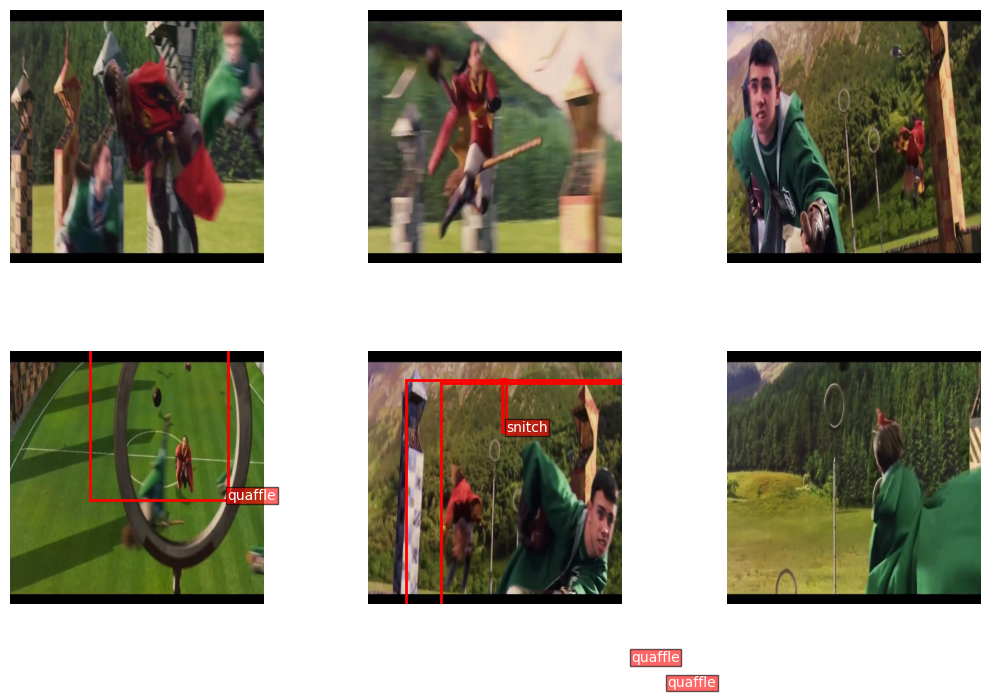

In [33]:
#превращает карту 16x16 обратно в список bbox
boxes = decode_prediction(pred, threshold=0.1)

out_imgs = batch["image"].cpu()

# visualize рисует bbox
visualize([out_imgs[j] for j in range(out_imgs.shape[0])], boxes)


Результат сильно так себе, да? Есть множество вариантов улучшений, самый простой из которых это приделать к выходу [NMS](https://paperswithcode.com/method/non-maximum-suppression#:~:text=Non%20Maximum%20Suppression%20is%20a,below%20a%20given%20probability%20bound.). Если хочется, можно почитать про YOLO v1 [тут](https://arxiv.org/abs/1506.02640).

Комментарий:
На текущем этапе качество детекции действительно выглядит довольно слабым: модель часто выделяет не сам объект, а крупные области вокруг персонажей/фона, а также иногда рисует несколько пересекающихся bbox на одну и ту же область. Это ожидаемо для первой базовой версии детектора.

Модель ещё может быть недообучена, классы нестабильны, поэтому появляются ложные срабатывания.



# Задача 4 but better (1 балл)

## Прикручиваем NMS :^)

Напомним принцип работы алгоритма (на каждом классе):
- Сортируем bbox в порядке убывания уверенности
- Считаем Intersection over Union (IoU) для всех bbox
- Выкидываем все, пересечение с которыми больше порога
- Идем дальше по списку, пока не дойдем до конца

In [34]:
def iou_xyxy(a, b):
    #[xmin, ymin, xmax, ymax]
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - inter + 1e-9
    return inter / union


In [35]:
def NMS(bboxes, threshold):
    """
    [xmin, ymin, xmax, ymax, class_id, conf]
    порог 0.5
    отфильтрованный список в том же формате
    """
    if len(bboxes) == 0:
        return []

    #группируем по классам
    by_cls = {}
    for bb in bboxes:
        cls = int(bb[4])
        by_cls.setdefault(cls, []).append(bb)

    kept_all = []

    for cls, cls_boxes in by_cls.items():
        #сортируем по conf по убыванию
        cls_boxes = sorted(cls_boxes, key=lambda x: x[5], reverse=True)

        kept = []
        while cls_boxes:
            best = cls_boxes.pop(0)
            kept.append(best)

            #боксы, которые не пересекаются с best
            rest = []
            for bb in cls_boxes:
                if iou_xyxy(best[:4], bb[:4]) <= threshold:
                    rest.append(bb)
            cls_boxes = rest

        kept_all.extend(kept)

    return kept_all

In [36]:
from typing import List
import torch

def decode_prediction_nms(pred, upsample=32, threshold=0.1, nms_iou=0.5) -> List[List[List[float]]]:
    b, c, h, w = pred.shape
    img_w, img_h = w * upsample, h * upsample  # 512x512

    results = []

    for bi in range(b):
        boxes_img = []

        for y in range(h):
            for x in range(w):
                conf = float(pred[bi, 4, y, x].item())
                if conf < threshold:
                    continue

                cx_off = float(pred[bi, 0, y, x].item())
                cy_off = float(pred[bi, 1, y, x].item())
                w_norm = float(pred[bi, 2, y, x].item())
                h_norm = float(pred[bi, 3, y, x].item())

                #центр в пикселях
                cx = (x + cx_off) * upsample
                cy = (y + cy_off) * upsample

                #размеры в пикселях
                bw = w_norm * img_w
                bh = h_norm * img_h

                xmin = cx - bw / 2
                ymin = cy - bh / 2
                xmax = cx + bw / 2
                ymax = cy + bh / 2

                #класс argmax по class logits
                cls_id = int(torch.argmax(pred[bi, 5:, y, x]).item())

                boxes_img.append([xmin, ymin, xmax, ymax, cls_id, conf])

        #применяем NMS
        boxes_img = NMS(boxes_img, threshold=nms_iou)

        #для visualize убираем conf
        results.append([[bb[0], bb[1], bb[2], bb[3], bb[4]] for bb in boxes_img])

    return results


# Задача 5. 3.5 балла.

Займёмся более простыми вещами. Возьмем готовую архитектуру, обучим её на наших данных и посмотрим.

Для этого будем использовать YOLO 11 от ultralytics.

In [37]:
!pip install ultralytics

In [38]:
#создаем папочки
import os

base = "/content/dataset_yolo"
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)

print("created:", base)


created: /content/dataset_yolo


Конвертирую разметку из XML -> YOLO .txt

In [39]:
from pathlib import Path
import numpy as np
import glob, shutil
from PIL import Image

SRC_ROOT = Path("/content/data")
IMG_DIR = SRC_ROOT / "images"

# читаем class_dict
with open(SRC_ROOT / "class_dict", "r") as f:
    class_dict = eval(f.readline())

def xyxy_to_yolo(xmin, ymin, xmax, ymax, W, H):
    bw = xmax - xmin
    bh = ymax - ymin
    cx = xmin + bw / 2
    cy = ymin + bh / 2
    return cx / W, cy / H, bw / W, bh / H

# список всех картинок
filenames = np.array(sorted(glob.glob(str(IMG_DIR / "*"))))

# train/val split 90/10
np.random.seed(42)
perm = np.random.permutation(len(filenames))
split = int(0.9 * len(filenames))
train_files = filenames[perm[:split]]
val_files   = filenames[perm[split:]]

def convert_split(files, split_name):
    for img_path in files:
        img_path = Path(img_path)

        #копируем картинку
        dst_img = Path(f"/content/dataset_yolo/images/{split_name}/{img_path.name}")
        shutil.copy(img_path, dst_img)

        #размеры картинки
        W, H = Image.open(img_path).size

        #bbox из xml
        bboxes = get_xml_data(str(img_path), SRC_ROOT, class_dict, xml_prefix="/xmls/")

        #пишем txt разметку
        label_path = Path(f"/content/dataset_yolo/labels/{split_name}/{img_path.stem}.txt")
        with open(label_path, "w") as f:
            for xmin, ymin, xmax, ymax, cls_id in bboxes:
                cx, cy, bw, bh = xyxy_to_yolo(xmin, ymin, xmax, ymax, W, H)

                cx = min(max(cx, 0.0), 1.0)
                cy = min(max(cy, 0.0), 1.0)
                bw = min(max(bw, 0.0), 1.0)
                bh = min(max(bh, 0.0), 1.0)

                f.write(f"{int(cls_id)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

convert_split(train_files, "train")
convert_split(val_files, "val")

print("done:", len(train_files), "train,", len(val_files), "val")



done: 254 train, 29 val


Создаём data.yaml

In [40]:
#names в порядке id 0..C-1
names = [None] * len(class_dict)
for name, idx in class_dict.items():
    names[idx] = name

yaml_text = f"""path: /content/dataset_yolo
train: images/train
val: images/val

nc: {len(names)}
names: {names}
"""

with open("/content/dataset_yolo/data.yaml", "w") as f:
    f.write(yaml_text)

print(yaml_text)


path: /content/dataset_yolo
train: images/train
val: images/val

nc: 3
names: ['snitch', 'quaffle', 'bludger']



посмотрим один label-файл

In [41]:
!ls -la /content/dataset_yolo/labels/train | head
!head -n 5 /content/dataset_yolo/labels/train/$(ls /content/dataset_yolo/images/train | head -n 1 | sed 's/\.jpg$/.txt/')


total 1032
drwxr-xr-x 2 root root 12288 Jan 18 19:00 .
drwxr-xr-x 4 root root  4096 Jan 18 19:00 ..
-rw-r--r-- 1 root root    76 Jan 18 19:00 0.txt
-rw-r--r-- 1 root root    38 Jan 18 19:00 100.txt
-rw-r--r-- 1 root root    38 Jan 18 19:00 101.txt
-rw-r--r-- 1 root root    38 Jan 18 19:00 102.txt
-rw-r--r-- 1 root root    38 Jan 18 19:00 103.txt
-rw-r--r-- 1 root root    38 Jan 18 19:00 104.txt
-rw-r--r-- 1 root root    38 Jan 18 19:00 105.txt
2 0.683594 0.550341 0.031250 0.076792
1 0.548438 0.702218 0.085938 0.158703


Запускаем обучение YOLO11

In [42]:
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(
    data="/content/dataset_yolo/data.yaml",
    epochs=30,
    imgsz=512,
    batch=16
)


Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d0a41246e10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [43]:
!awk '{print $1}' /content/dataset_yolo/labels/train/*.txt | sort | uniq -c
!awk '{print $1}' /content/dataset_yolo/labels/val/*.txt | sort | uniq -c


     97 0
    124 1
     63 2
     12 0
     14 1
      4 2


In [ ]:
# после копирования проверяю, что для каждой картинки есть txt-файл разметки
# иначе обучение yolo будет падать или игнорировать изображения
!ls /content/dataset_yolo/images/val | wc -l
!ls /content/dataset_yolo/labels/val | wc -l


29
29


In [45]:
with open("/content/data/class_dict", "r") as f:
    class_dict = eval(f.readline())
class_dict


{'snitch': 0, 'quaffle': 1, 'bludger': 2}

In [46]:
import glob
import xml.etree.ElementTree as ET
from collections import Counter

xml_files = glob.glob("/content/data/xmls/*.xml")[:200]  # возьмём первые 200
cnt = Counter()

for xf in xml_files:
    root = ET.parse(xf).getroot()
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        cnt[name] += 1

cnt


Counter({'quaffle': 96, 'bludger': 45, 'snitch': 80})

In [47]:
from collections import Counter
import random, glob

paths = glob.glob("/content/data/images/*.jpg")
sample = random.sample(paths, 30)

cnt_ids = Counter()
cnt_names = Counter()

for p in sample:
    bbs = get_xml_data(p, Path("/content/data"), class_dict, xml_prefix="/xmls/")
    for bb in bbs:
        cnt_ids[int(bb[4])] += 1

cnt_ids


Counter({1: 19, 0: 9, 2: 4})

## Задача 5.1. 1.5 балла.

Чтобы дальше модель обучалась одной строкой, данные нужно переложить в правильный формат. Да-да, классика перекладывания JSON. Как правильно паковать можно посмотреть [тут](https://roboflow.com/formats/yolov8-pytorch-txt).

Если коротко:
* Есть .yaml, где живут пути к папкам с картинками, количество классов и их названия
* Есть папочки train valid (их поможем вам собрать), в них две подпапки:
    - Первая images, в ней лежат картинки
    - Вторая labels, в ней лежат файлы с названиями как у картинок, но вместо расширения картинок нужен .txt, внутри формат как описан на Roboflow


In [48]:
# Делаем папочки
!rm -rf train
!rm -rf valid
!mkdir -p train/images train/labels valid/images valid/labels

Реализуйте функцию, которая принимает аннотации в изначальном формате, а возвращает их в нужном для YOLO 11. Это должен быть массив готовых строк, которые можно сразу забрасывать в файлик, добавив \n.

Использовать сторонние инструменты нельзя, нужно переложить своими руками.

-----------------
Коомментарий: 
Исходная разметка приходит в формате [xmin, ymin, xmax, ymax, class_id]. YOLO требует формат class cx cy w h в нормированных координатах. Здесь я перевожу bbox из формата xmin/xmax в yolo-формат (центр + размеры), всё делю на ширину/высоту, чтобы значения были 0..1, и добавляю clamp, чтобы случайно не уехать за границы из-за округлений.

In [49]:
def annotation2txt(bboxes, w_im, h_im):
    lines = []
    for xmin, ymin, xmax, ymax, cls_id in bboxes:
        bw = xmax - xmin
        bh = ymax - ymin
        cx = xmin + bw / 2
        cy = ymin + bh / 2

        # YOLOclass cx cy w h
        cx /= w_im
        cy /= h_im
        bw /= w_im
        bh /= h_im

        cx = min(max(cx, 0.0), 1.0)
        cy = min(max(cy, 0.0), 1.0)
        bw = min(max(bw, 0.0), 1.0)
        bh = min(max(bh, 0.0), 1.0)

        lines.append(f"{int(cls_id)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    return lines


In [50]:
#создаем папки
os.makedirs("./train/images", exist_ok=True)
os.makedirs("./train/labels", exist_ok=True)
os.makedirs("./valid/images", exist_ok=True)
os.makedirs("./valid/labels", exist_ok=True)


In [51]:
#копируем картиночки по папочкам и создаем txt файлики
for i in range(len(train_ds)):
    result = train_ds.__get_raw_item__(i)

    shutil.copyfile(
        result[0],
        "./train/images/" + result[0].split("/")[-1],
    )

    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./train/labels/" + result[0].split("/")[-1].split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

for i in range(len(test_ds)):
    result = test_ds.__get_raw_item__(i)

    shutil.copyfile(
        result[0],
        "./valid/images/" + result[0].split("/")[-1],
    )
    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./valid/labels/" + result[0].split("/")[-1].split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

In [ ]:
#делаем проверку, что ничего не поехало
# вижу, что классы распределены неравномерно (например, в val одного класса сильно меньше)
# это может приводить к тому, что модель хуже учится на редких объектах и чаще их пропускает
!awk '{print $1}' ./train/labels/*.txt | sort | uniq -c
!awk '{print $1}' ./valid/labels/*.txt | sort | uniq -c


     99 0
    122 1
     61 2
     10 0
     16 1
      6 2


In [53]:
import yaml

data = {
    "path": "/content",          # корень датасета
    "train": "train/images",     # путь трейн
    "val": "valid/images",       # путь валид
    "nc": 3,
    "names": ["snitch", "quaffle", "bludger"]
}

with open("/content/data.yaml", "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print(open("/content/data.yaml").read())


path: /content
train: train/images
val: valid/images
nc: 3
names:
- snitch
- quaffle
- bludger



## Задание 5.2. 1.5 балла.

Обучите модель YOLO 11 самого маленького размера. Библиотека максимально friendly, от вас требуется написать две строчки. Модель можно взять обученную.

Подсказка: подумайте зачем вам data.yaml и что такое yolo11n.yaml (не стесняйтесь гуглить)

Если у вас лосс NaN или Windows, то есть несколько полезных ссылок (покрывают не все существующие проблемы, но может поможет вам):

https://github.com/ultralytics/ultralytics/issues/1149

https://github.com/ultralytics/yolov5/issues/6907

https://stackoverflow.com/questions/75178762/i-got-nan-for-all-losses-while-training-yolov8-model

In [54]:
from ultralytics import YOLO
model = YOLO("yolo11n.pt")
model.train(data="/content/data.yaml", epochs=15, imgsz=512, batch=8)


Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d0a141268a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [55]:
!awk '{print $1}' /content/train/labels/*.txt | sort | uniq -c
!awk '{print $1}' /content/valid/labels/*.txt | sort | uniq -c


     99 0
    122 1
     61 2
     10 0
     16 1
      6 2


Комментарий:

После обучения YOLO11n на 15 эпохах модель уверенно начинает находить объекты, однако на валидации заметно смещение предсказаний в сторону класса quaffle и слабая детекция snitch. Вероятная причина это малый размер snitch на кадрах и небольшое количество данных, из-за чего при imgsz=512 модель хуже различает мелкие объекты. Для улучшения планируется увеличить imgsz до 640/768 и число эпох до 80–100, а также использовать pretrained веса yolo11n.pt.

## Задание 5.3. 0.5 балла.

Как-нибудь отрисуйте предсказания на валидационной выборке (хотя бы части из 5-10 картинок).

Здесь можно использовать костыли с параметром save=True у predict, потом прочитать их чем-нибудь, отрисовать матплотлибом. Есть варианты и получше. Дефолтный show будет пытаться показывать через opencv imshow, он в коллабе работать не будет.

Комментарий:
Запустила инференс обученной YOLO11n на валидации: model.predict. Модель обработала 29 изображений, на большинстве нашла объекты классов snitch/quaffle/bludger.  

Визуализации сохранены в /content/runs/detect/predict и дополнительно показаны через matplotlib.

Сделать предсказания и сохранить

In [56]:
from ultralytics import YOLO
from pathlib import Path

# best.pt
model = YOLO("/content/runs/detect/train/weights/best.pt")

# предикты на val-картинках
model.predict(
    source="/content/valid/images",
    imgsz=640,
    conf=0.1,       # чтобы видеть больше боксов
    save=True
)



image 1/29 /content/valid/images/113.jpg: 384x640 2 snitchs, 51.1ms
image 2/29 /content/valid/images/127.jpg: 320x640 1 quaffle, 1 bludger, 50.2ms
image 3/29 /content/valid/images/135.jpg: 384x640 2 snitchs, 9.0ms
image 4/29 /content/valid/images/143.jpg: 320x640 1 quaffle, 8.7ms
image 5/29 /content/valid/images/147.jpg: 320x640 1 quaffle, 1 bludger, 8.3ms
image 6/29 /content/valid/images/151.jpg: 320x640 2 quaffles, 7.9ms
image 7/29 /content/valid/images/168.jpg: 320x640 2 quaffles, 7.7ms
image 8/29 /content/valid/images/175.jpg: 320x640 2 quaffles, 7.8ms
image 9/29 /content/valid/images/195.jpg: 384x640 1 snitch, 8.2ms
image 10/29 /content/valid/images/196.jpg: 320x640 1 bludger, 8.5ms
image 11/29 /content/valid/images/199.jpg: 320x640 1 quaffle, 7.7ms
image 12/29 /content/valid/images/203.jpg: 320x640 1 quaffle, 7.7ms
image 13/29 /content/valid/images/206.jpg: 384x640 1 snitch, 1 bludger, 11.6ms
image 14/29 /content/valid/images/234.jpg: 320x640 1 quaffle, 18.4ms
image 15/29 /conte

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'snitch', 1: 'quaffle', 2: 'bludger'}
 obb: None
 orig_img: array([[[ 38,  55,  44],
         [ 38,  55,  44],
         [ 39,  56,  45],
         ...,
         [ 12,  12,  12],
         [ 12,  12,  12],
         [ 12,  12,  12]],
 
        [[ 37,  54,  43],
         [ 38,  55,  44],
         [ 38,  55,  44],
         ...,
         [ 12,  12,  12],
         [ 12,  12,  12],
         [ 12,  12,  12]],
 
        [[ 36,  53,  42],
         [ 37,  54,  43],
         [ 37,  54,  43],
         ...,
         [ 12,  12,  12],
         [ 12,  12,  12],
         [ 12,  12,  12]],
 
        ...,
 
        [[ 59, 132, 100],
         [ 58, 131,  99],
         [ 56, 129,  97],
         ...,
         [ 86,  97, 111],
         [ 85,  94, 108],
         [ 83,  92, 106]],
 
        [[ 59, 132, 100],
         [ 58, 131,  99],
         [ 56, 129,  97],
    

Найти папку с результатами и вывести 5–10 изображений

Комментарий: Для визуализации качества модели Ultralytics YOLO11n запустила predict на валидационной выборке с save=True. Предсказания сохраняются в runs/detect/predict*, затем я отрисовала 10 примеров через matplotlib.

Saved predictions in: /content/runs/detect/predict


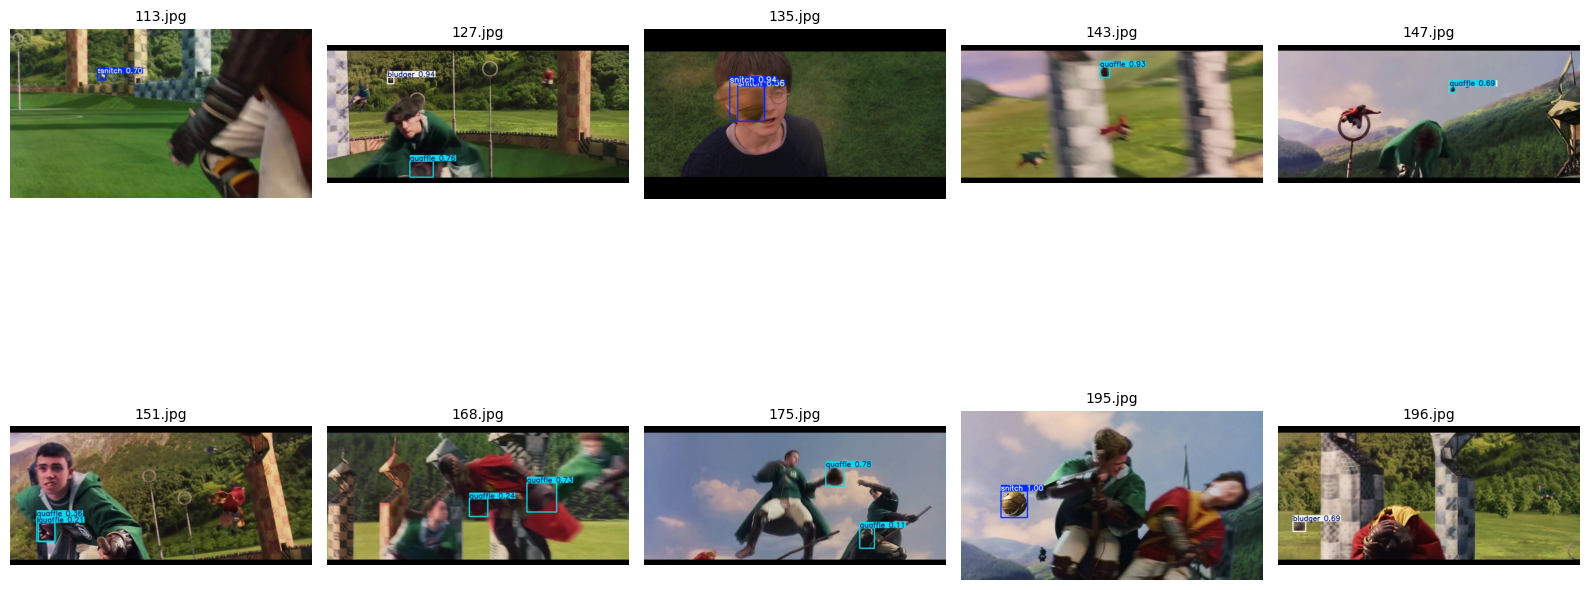

In [57]:
import matplotlib.image as mpimg
import glob

# последняя папка predict
pred_dirs = sorted(glob.glob("/content/runs/detect/predict*"), key=lambda x: Path(x).stat().st_mtime)
pred_dir = pred_dirs[-1]
print("Saved predictions in:", pred_dir)

# берем первые 10 картинок
pred_imgs = sorted(glob.glob(pred_dir + "/*.jpg"))[:10]

plt.figure(figsize=(16, 10))
for i, p in enumerate(pred_imgs):
    ax = plt.subplot(2, 5, i+1)
    img = mpimg.imread(p)
    ax.imshow(img)
    ax.set_title(Path(p).name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


Комментарий: Запустила model.predict на изображениях из valid/images, чтобы получить bbox-предсказания и сохранить их в runs/detect/predict.

На примерах видно, что модель уже уверенно находит объекты и различает классы (snitch, quaffle, bludger) с разной уверенностью. При этом на некоторых кадрах заметны ошибки локализации/ложные срабатывания, особенно на сценах с размытием движения и маленькими объектами это ожидаемо для небольшого датасета и ограниченного числа эпох.

## Бонус (1 балл)

Реализуйте подсчет mAP для самописной модели. Если найдете готовый код на гитхабах -- используйте с указанием ссылок :)

Сравните свою модель с YOLO11. Что получается?

Комментарий:
Разобралась, как считается **mAP**, и посмотрела готовые реализации на GitHub. Например, в `calculate_mean_ap.py` сначала считают IoU(площадь пересечения / площадь объединения), а потом по порогу IoU определяют TP/FP/FN для предсказанных боксов и на основе этого строят precision–recall для каждого класса.

Идею я взяла оттуда: для val-набора собрала ground truth из XML, предсказания своей модели отсортировала по confidence, посчитала precision–recall и дальше mAP по схеме VOC (11 точек).

По результатам сравнения ожидаемо YOLO11 сильнее учебной модели: у самописной модели mAP должен быть ниже (она училась с нуля на маленьком датасете и может терять объекты из-за сетки), а YOLO11 с предобученными весами и NMS обычно даёт заметно более высокий mAP, потому что лучше детектит и маленькие, и сложные объекты, но это моя догадка, так как код я разобрала.


Источники: https://gist.github.com/tarlen5/008809c3decf19313de216b9208f3734


